## L_01_4. Vectors. Geodesics

In this notebook one handles and illustrates vectors and geodesics. 

(1) __Vectors__. In the case of the Euclidean space, if once considers a vector, both the origin and the endpoint are elements of the manifold. In the case of a manifold (e.g. a sphere), it makes sense to consider only the origin as element of the manifold. 

(2) __Geodesics__. A geodesic on a Riemannian manifold $M$ (on such a manifold one can measure distances between points) is a curve whose image is included in $M$. Empirically, a geodesic is a shortest length curve. The formal definition is, however, more sophisticated and requires additional concepts. Two examples of geodesics are provided: for the sphere and for the hyperbolic plane.

### Initializations

In [1]:
### Initialization 
import os
import subprocess
print('Working directory: ', os.getcwd())
import geomstats.backend as gs

import matplotlib
import matplotlib.image as mpimg
import matplotlib.pyplot as plt
from matplotlib import rcParams

import geomstats.visualization as visualization
gs.random.seed(2020)
visualization.tutorial_matplotlib()

# Global rcParams
rcParams["font.family"] = "sans-serif"
rcParams["font.serif"] = ["Times New Roman"]
rcParams["font.sans-serif"] = ["Arial"]
rcParams["font.monospace"] = ["Courier New"]
rcParams["mathtext.fontset"] = "custom"
rcParams["mathtext.rm"] = "Times New Roman"
rcParams["mathtext.it"] = "Times New Roman:italic"
rcParams["mathtext.bf"] = "Times New Roman:bold"

Working directory:  d:\Documents\FMI\Master Anul II\EDDL\Laborator


### Points and vectors in the Euclidean space R^2

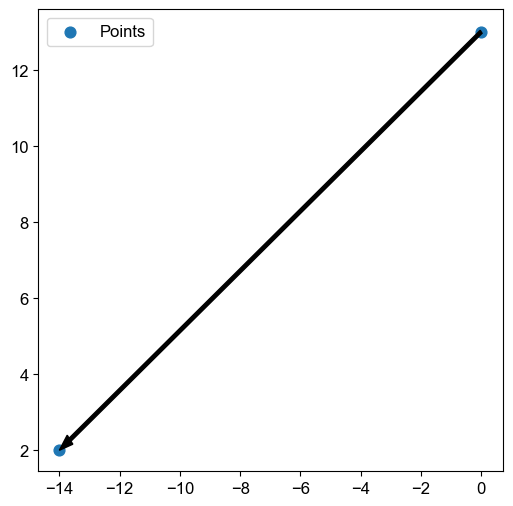

In [2]:
### Operations with points and vectors
%matplotlib inline

fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(111)
xa = 0
ya = 13
xb = -14
yb = 2
point_a = gs.array([xa, ya])
point_b = gs.array([xb, yb])
vector = point_b-point_a
x = gs.array([xa, xb])
y = gs.array([ya, yb])
ax.scatter(x, y, s=60, label='Points')
ax.arrow(gs.to_numpy(point_a[0]), gs.to_numpy(point_a[1]),
         dx=gs.to_numpy(vector[0]), dy=gs.to_numpy(vector[1]),
         width=0.1, length_includes_head=True, color='black')


ax.legend();

### Vectors with origin on the sphere. Geodesics on the sphere

In [3]:
### Import manifold and data: cities data on the sphere
from geomstats.geometry.hypersphere import Hypersphere
sphere = Hypersphere(dim=2)
import geomstats.datasets.utils as data_utils
data, names = data_utils.load_cities()

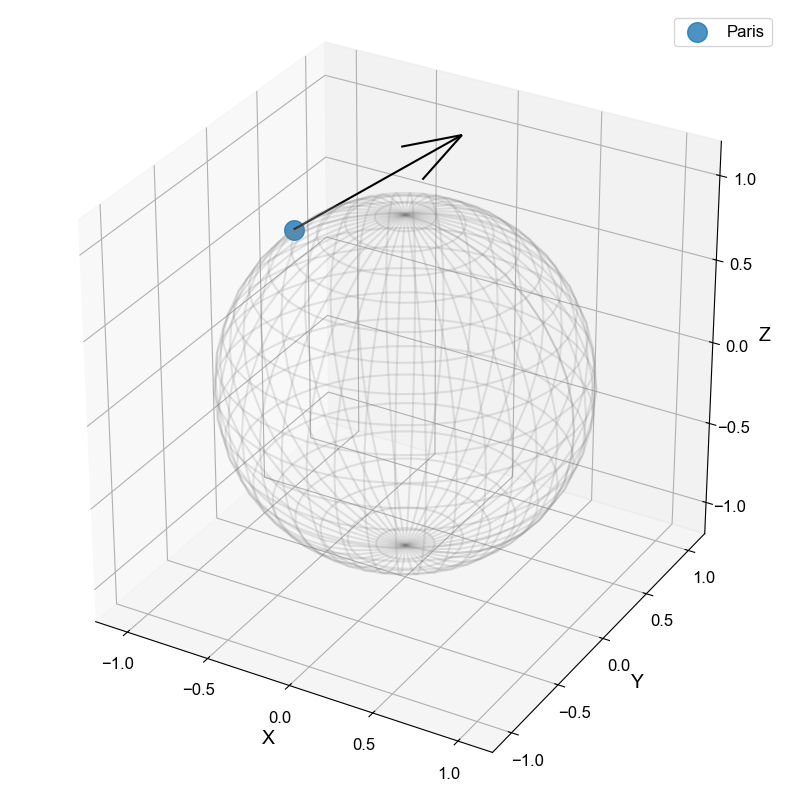

In [4]:
### Vector with origin on the sphere. One takes advantage of the sphere embedding in R^3.
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')

a=19
city = data[a]
vector = gs.array([1, 0, 0.8]) # A 3D-vector, in R^3.

ax = visualization.plot(city, ax=ax, space='S2', s=200, alpha=0.8, label=names[a])
arrow = visualization.Arrow3D(city, vector=vector)
arrow.draw(ax, color='black')
ax.legend();


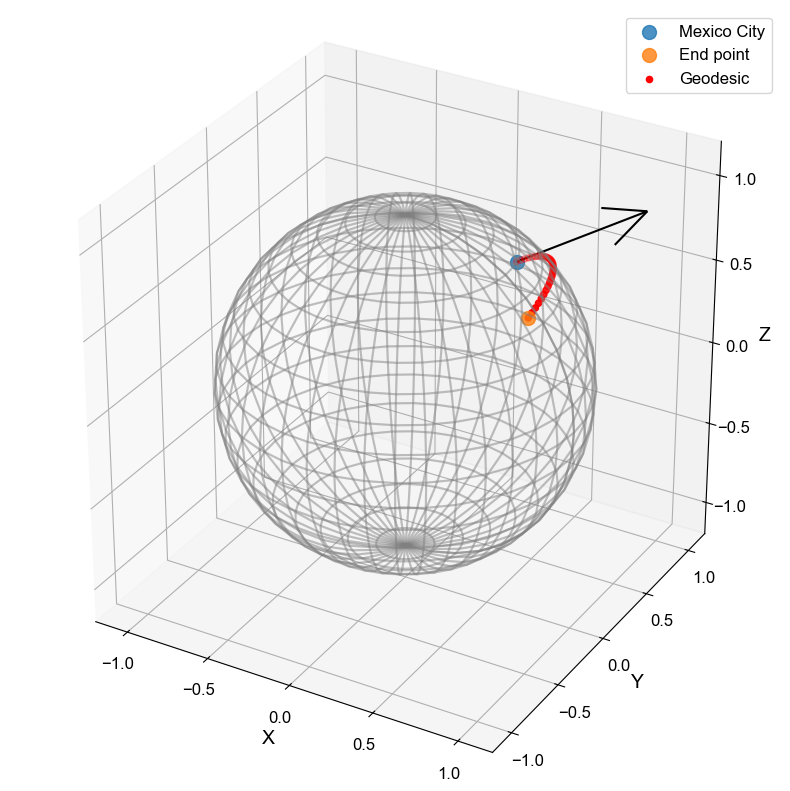

In [5]:
### Exponential map. Generate geodesic starting from a point/city and induced by a vector
a=2
city = data[a]
vector = gs.array([1, -0.3, 0.8]) ## take care what happens when the vector is not a tangent vector!
tangent_vector = sphere.to_tangent(vector, base_point=city)

result = sphere.metric.exp(tangent_vector, base_point=city)

geodesic = sphere.metric.geodesic(
        initial_point=city,
        initial_tangent_vec=tangent_vector)

points_on_geodesic = geodesic(gs.linspace(0., 1., 30)) 

# Visualization
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')
ax = visualization.plot(city, ax=ax, space='S2', s=100, alpha=0.8, label=names[a])
ax = visualization.plot(result, ax=ax, space='S2', s=100, alpha=0.8, label='End point')
ax = visualization.plot(
    points_on_geodesic, ax=ax, space='S2', color='red', label='Geodesic')

arrow = visualization.Arrow3D(city, vector=tangent_vector)
arrow.draw(ax, color='black')
ax.legend();

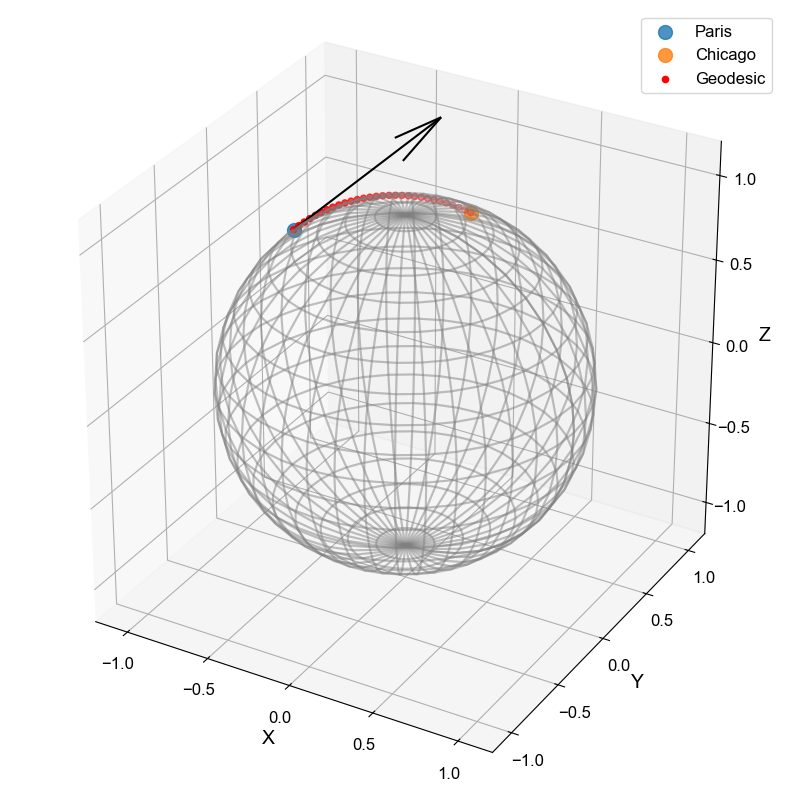

In [6]:
### Logarithm map. Generate a geodesic joining two points
a=19
b=24
start_city = data[a]
end_city = data[b]

log = sphere.metric.log(point=end_city, base_point=start_city)

geodesic = sphere.metric.geodesic(
        initial_point=start_city,
        end_point=end_city)

points_on_geodesic = geodesic(gs.linspace(0., 1., 30))
# Visualization
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')

ax = visualization.plot(start_city, ax=ax, space='S2', s=100, alpha=0.8, label=names[a])
ax = visualization.plot(end_city, ax=ax, space='S2', s=100, alpha=0.8, label=names[b])
ax = visualization.plot(
    points_on_geodesic, ax=ax, space='S2', color='red', label='Geodesic')

arrow = visualization.Arrow3D(start_city, vector=log)
arrow.draw(ax, color='black')
ax.legend();

### Another example of geodesics - the case of the hyperbolic plane

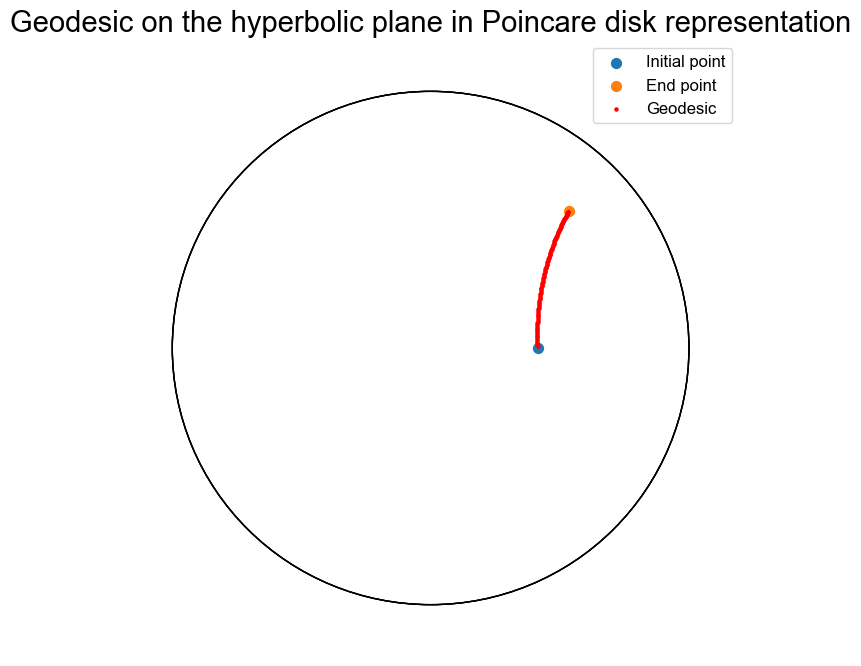

In [7]:
### Geodesics on the hyperbolic plane in Poincare disk model
from geomstats.geometry.hyperboloid import Hyperboloid

hyperbolic = Hyperboloid(dim=2)

initial_point = gs.array([gs.sqrt(2.), 1., 0.])
end_point = gs.array([2.5, 2.5])
end_point = hyperbolic.from_coordinates(end_point, 'intrinsic')

geodesic = hyperbolic.metric.geodesic(
    initial_point=initial_point, end_point=end_point)

points = geodesic(gs.linspace(0., 1., 100))
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111)

representation = 'H2_poincare_disk'

ax = visualization.plot(
    initial_point, ax=ax, space=representation, s=50, label='Initial point');
ax = visualization.plot(
    end_point, ax=ax, space=representation, s=50, label='End point');

ax = visualization.plot(
    points[1:-1], ax=ax, space=representation, s=5, color='red', label='Geodesic');
ax.set_title('Geodesic on the hyperbolic plane in Poincare disk representation')
ax.legend();

(i) PLANE VECTORS IN R^2
Point A: [1. 2.]
Point B: [4. 6.]
Vector A->B: [3. 4.]
Vector magnitude: 5.000000


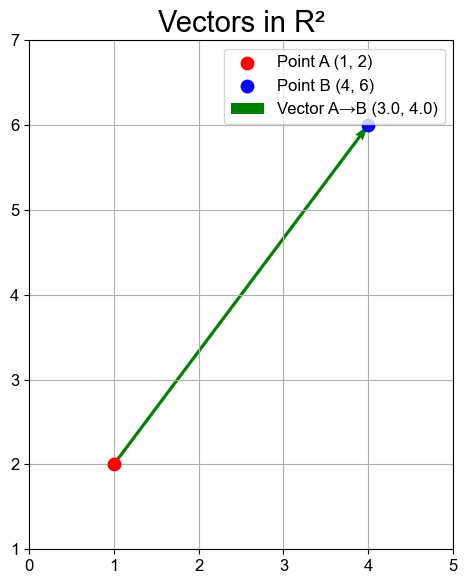

(ii-iv) VECTORS AND GEODESICS ON S^2
Origin on S^2: [1. 0. 0.], belongs: True
Tangent vector (proiectat): [0.  1.  0.5]
Dot(origin, tangent) ≈ 0: 0.00e+00
Geodesic distance origin→end: 1.570796
Expected (π/2 ≈ 1.5708): 1.570796


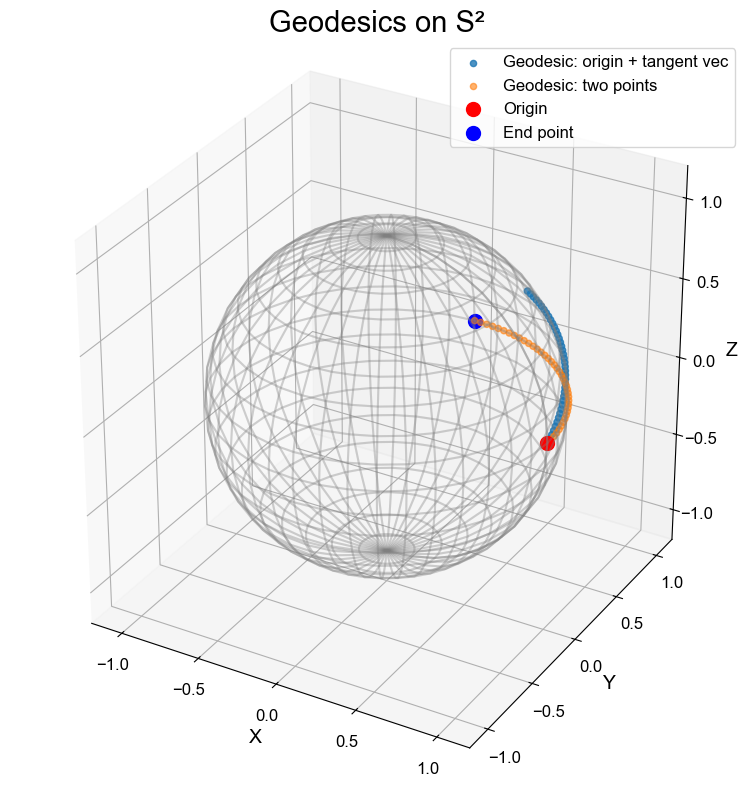

(v) GEODESIC IN HYPERBOLIC PLANE (POINCARE DISK)
Start belongs to H²: True
End   belongs to H²: True
Hyperbolic distance: 1.214890


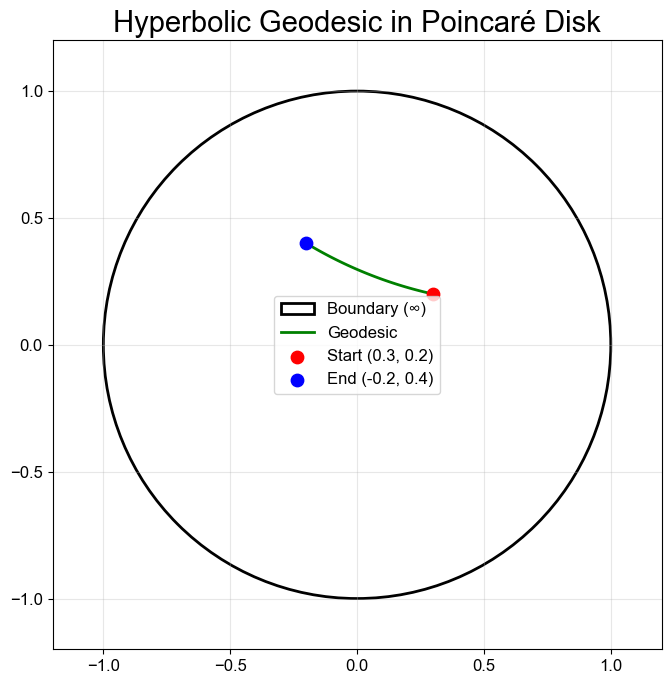

: 

In [ ]:
### Exploration: vectors and geodesics — FIXED
from geomstats.geometry.hypersphere import Hypersphere
from geomstats.geometry.poincare_ball import PoincareBall
import geomstats.backend as gs
import geomstats.visualization as visualization
import matplotlib.pyplot as plt

# ──────────────────────────────────────────────
# (i) PLANE VECTORS IN R^2
# ──────────────────────────────────────────────
print("="*60)
print("(i) PLANE VECTORS IN R^2")
print("="*60)

point_a = gs.array([1.0, 2.0])
point_b = gs.array([4.0, 6.0])
vector_ab = point_b - point_a
print(f"Point A: {point_a}")
print(f"Point B: {point_b}")
print(f"Vector A->B: {vector_ab}")
print(f"Vector magnitude: {gs.linalg.norm(vector_ab):.6f}")

fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(111)

# FIX 1: Arată A și B ca puncte, nu ca vectori de poziție din origine —
#         mai clar conceptual pentru "vectors in R^2"
ax.scatter(*point_a, color='red', s=80, zorder=5, label='Point A (1, 2)')
ax.scatter(*point_b, color='blue', s=80, zorder=5, label='Point B (4, 6)')

# Vectorul A→B pornind din A
ax.quiver(
    point_a[0], point_a[1],
    vector_ab[0], vector_ab[1],
    angles='xy', scale_units='xy', scale=1,
    color='green', label=f'Vector A→B {tuple(vector_ab.tolist())}'
)

# FIX 2: Limite explicite ca să fie vizibili toți vectorii
padding = 1.0
ax.set_xlim(min(point_a[0], point_b[0]) - padding,
            max(point_a[0], point_b[0]) + padding)
ax.set_ylim(min(point_a[1], point_b[1]) - padding,
            max(point_a[1], point_b[1]) + padding)

ax.set_aspect('equal')
ax.grid(True)
ax.legend()
ax.set_title('Vectors in R²')
plt.tight_layout()
plt.show()


# ──────────────────────────────────────────────
# (ii-iv) VECTORS AND GEODESICS ON S^2
# ──────────────────────────────────────────────
print("="*60)
print("(ii-iv) VECTORS AND GEODESICS ON S^2")
print("="*60)

sphere = Hypersphere(dim=2)
origin = gs.array([1.0, 0.0, 0.0])
tangent = gs.array([0.0, 1.0, 0.5])           # vector tangent arbitrar
tangent = sphere.to_tangent(tangent, base_point=origin)  # proiectat pe spațiul tangent

print(f"Origin on S^2: {origin}, belongs: {sphere.belongs(origin)}")
print(f"Tangent vector (proiectat): {tangent}")
print(f"Dot(origin, tangent) ≈ 0: {gs.dot(origin, tangent):.2e}")  # trebuie ~0

times = gs.linspace(0.0, 1.0, 40)

# FIX 3: Geodezică din punct + vector tangent — folosește .geodesic(), nu .exp() vectorizat
geo_fn_from_vector = sphere.metric.geodesic(
    initial_point=origin,
    initial_tangent_vec=tangent
)
geo_from_vector = geo_fn_from_vector(times)

# FIX 4: Geodezică din două puncte — la fel
point_end = gs.array([0.0, 1.0, 0.0])
geo_fn_two_points = sphere.metric.geodesic(
    initial_point=origin,
    end_point=point_end
)
geo_two_points = geo_fn_two_points(times)

print(f"Geodesic distance origin→end: {sphere.metric.dist(origin, point_end):.6f}")
print(f"Expected (π/2 ≈ 1.5708): {gs.pi / 2:.6f}")

fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')
visualization.plot(geo_from_vector, ax=ax, space='S2',
                   label='Geodesic: origin + tangent vec', s=20, alpha=0.8)
visualization.plot(geo_two_points, ax=ax, space='S2',
                   label='Geodesic: two points', s=20, alpha=0.6)
ax.scatter(*origin, s=100, c='red', label='Origin', zorder=5)
ax.scatter(*point_end, s=100, c='blue', label='End point', zorder=5)
ax.legend()
ax.set_title('Geodesics on S²')
plt.tight_layout()
plt.show()


# ──────────────────────────────────────────────
# (v) GEODESIC IN HYPERBOLIC PLANE (POINCARÉ DISK)
# ──────────────────────────────────────────────
print("="*60)
print("(v) GEODESIC IN HYPERBOLIC PLANE (POINCARE DISK)")
print("="*60)

hyper = PoincareBall(dim=2)
h_start = gs.array([0.3, 0.2])
h_end   = gs.array([-0.2, 0.4])

print(f"Start belongs to H²: {hyper.belongs(h_start)}")
print(f"End   belongs to H²: {hyper.belongs(h_end)}")

# FIX 5: Geodezică în Poincaré — folosește .geodesic(), nu .exp() vectorizat
geo_fn_hyp = hyper.metric.geodesic(
    initial_point=h_start,
    end_point=h_end
)
h_geo = geo_fn_hyp(times)

print(f"Hyperbolic distance: {hyper.metric.dist(h_start, h_end):.6f}")

fig = plt.figure(figsize=(7, 7))
ax = fig.add_subplot(111)

# Marginea discului (= "infinitul" planului hiperbolic)
boundary = plt.Circle((0, 0), 1, color='black', fill=False, linewidth=2, label='Boundary (∞)')
ax.add_patch(boundary)

ax.plot(h_geo[:, 0], h_geo[:, 1], 'g-', linewidth=2, label='Geodesic')
ax.scatter(*h_start, c='red',  s=80, zorder=5, label=f'Start {tuple(h_start.tolist())}')
ax.scatter(*h_end,   c='blue', s=80, zorder=5, label=f'End {tuple(h_end.tolist())}')

ax.set_xlim(-1.2, 1.2)
ax.set_ylim(-1.2, 1.2)
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
ax.legend()
ax.set_title('Hyperbolic Geodesic in Poincaré Disk')
plt.tight_layout()
plt.show()

### Exercise 2: Geodesic Distance on $S^2$
Given:
- $A=(0,1,0)$
- $B=(0,0,1)$

On the unit sphere, the geodesic distance is computed with the sphere metric.

In [ ]:
### Exercise 2: geodesic distance on S^2 between A and B
from geomstats.geometry.hypersphere import Hypersphere

sphere = Hypersphere(dim=2)
A = gs.array([0.0, 1.0, 0.0])
B = gs.array([0.0, 0.0, 1.0])

# Geodesic distance via the Riemannian metric on the sphere
d_sphere = sphere.metric.dist(A, B)

# Analytical check on the unit sphere: dist(A,B)=arccos(<A,B>)
dot_AB = gs.dot(A, B)
analytic = gs.arccos(dot_AB)

print("Exercise 2")
print(f"A belongs to S^2: {sphere.belongs(A)}")
print(f"B belongs to S^2: {sphere.belongs(B)}")
print(f"<A,B> = {dot_AB}")
print(f"Geodesic distance d_S2(A,B) = {d_sphere:.12f}")
print(f"Analytical arccos(<A,B>) = {analytic:.12f}")
print(f"Value in multiples of pi: {d_sphere / gs.pi:.6f} * pi")

Exercise 2
A belongs to S^2: True
B belongs to S^2: True
<A,B> = 0.0
Geodesic distance d_S2(A,B) = 1.570796326795
Analytical arccos(<A,B>) = 1.570796326795
Value in multiples of pi: 0.500000 * pi


### Exercise 3: Distance in $\mathrm{SPD}(2)$ with Affine-Invariant Metric
Given:
- $A=\begin{pmatrix}1&0\\0&1\end{pmatrix}$
- $B=\begin{pmatrix}2&1\\1&2\end{pmatrix}$

We compute the affine-invariant Riemannian distance using the default metric of the SPD manifold.

In [ ]:
### Exercise 3: affine-invariant distance in SPD(2)
from geomstats.geometry.spd_matrices import SPDMatrices

spd2 = SPDMatrices(n=2)
A = gs.array([[1.0, 0.0],
              [0.0, 1.0]])
B = gs.array([[2.0, 1.0],
              [1.0, 2.0]])

# Affine-invariant metric distance on SPD(2)
d_spd = spd2.metric.dist(A, B)

# Analytical check since A = I: d(A,B)=||log(B)||_F = sqrt(sum(log(lambda_i)^2))
eigs = gs.linalg.eigvalsh(B)
analytic = gs.sqrt(gs.sum(gs.log(eigs) ** 2))

print("Exercise 3")
print(f"A belongs to SPD(2): {spd2.belongs(A)}")
print(f"B belongs to SPD(2): {spd2.belongs(B)}")
print(f"Eigenvalues of B: {eigs}")
print(f"Affine-invariant distance d_SPD(A,B) = {d_spd:.12f}")
print(f"Analytical value sqrt(sum(log(lambda_i)^2)) = {analytic:.12f}")

Exercise 3
A belongs to SPD(2): True
B belongs to SPD(2): True
Eigenvalues of B: [1. 3.]
Affine-invariant distance d_SPD(A,B) = 1.098612288668
Analytical value sqrt(sum(log(lambda_i)^2)) = 1.098612288668


In [ ]:
### Geomstats tutorial experiment: learning on tangent spaces
import geomstats.datasets.utils as data_utils
from geomstats.geometry.spd_matrices import (
    SPDAffineMetric,
    SPDLogEuclideanMetric,
    SPDMatrices,
)
from geomstats.learning.preprocessing import ToTangentSpace
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_validate
from sklearn.pipeline import Pipeline

gs.random.seed(2020)

data, patient_ids, labels = data_utils.load_connectomes()
flat_data, _, _ = data_utils.load_connectomes(as_vectors=True)

manifold = SPDMatrices(28, equip=False)
spd_ai = SPDMatrices(28, equip=False)
spd_ai.equip_with_metric(SPDAffineMetric)
spd_le = SPDMatrices(28, equip=False)
spd_le.equip_with_metric(SPDLogEuclideanMetric)

pipeline_ai = Pipeline([
    ("feature_ext", ToTangentSpace(space=spd_ai)),
    ("classifier", LogisticRegression(C=2, max_iter=1000)),
])
result_ai = cross_validate(pipeline_ai, data, labels)

pipeline_le = Pipeline([
    ("feature_ext", ToTangentSpace(space=spd_le)),
    ("classifier", LogisticRegression(C=2, max_iter=1000)),
])
result_le = cross_validate(pipeline_le, data, labels)

result_euclid = cross_validate(LogisticRegression(max_iter=1000), flat_data, labels)

print("Geomstats tutorial experiment: simple ML on tangent spaces")
print(f"Connectomes shape: {data.shape}")
print(f"Flattened shape: {flat_data.shape}")
print(f"Number of patients: {len(patient_ids)}")
print(f"All matrices belong to SPD(28): {gs.all(manifold.belongs(data))}")
print(f"Affine-invariant mean accuracy: {result_ai['test_score'].mean():.6f}")
print(f"Log-Euclidean mean accuracy: {result_le['test_score'].mean():.6f}")
print(f"Euclidean baseline mean accuracy: {result_euclid['test_score'].mean():.6f}")

Geomstats tutorial experiment: simple ML on tangent spaces
Connectomes shape: (86, 28, 28)
Flattened shape: (86, 378)
Number of patients: 86
All matrices belong to SPD(28): True
Affine-invariant mean accuracy: 0.709804
Log-Euclidean mean accuracy: 0.686275
Euclidean baseline mean accuracy: 0.733333
